# ST446 Project: Stacking Ensemble (LR + RF only)

This notebook builds a stacking ensemble for the ST446 flight delay project using the previous **Logistic Regression** and **Random Forest** as base learners, with **Logistic Regression** as the meta-model.

- **Layer 1**: On-time vs late (`is_late`)
- **Layer 2**: Minor vs major delay (`delay_severity`) on late flights only
- **Train/test split**: 2019–2021 train, 2022 test

This notebook uses **out-of-fold predictions** to train the meta-model and avoid leakage

## 1. Imports & Spark setup

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, lit, array, avg, min as spark_min, max as spark_max
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.functions import vector_to_array

sns.set_theme(style="whitegrid", palette="muted")

spark = SparkSession.builder.appName("ST446-Stacking").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/04 08:44:56 INFO SparkEnv: Registering MapOutputTracker
26/05/04 08:44:56 INFO SparkEnv: Registering BlockManagerMaster
26/05/04 08:44:56 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/05/04 08:44:56 INFO SparkEnv: Registering OutputCommitCoordinator


Spark version: 3.5.3


## 2. Load data and split

In [2]:
df = spark.read.parquet("gs://dataproc-staging-europe-west2-829626506332-qfvhtjuq/notebooks/jupyter/*.parquet")
print(f"Total rows: {df.count():,}")
print("Columns:", df.columns)

train = df.filter(col("year") <= 2021)
test = df.filter(col("year") == 2022)

print(f"Layer 1 train rows: {train.count():,}")
print(f"Layer 1 test rows: {test.count():,}")
print(f"Train/test split: {100*train.count()/df.count():.1f}% / {100*test.count()/df.count():.1f}%")

Total rows: 3,480,548
Columns: ['features', 'year', 'delay_class', 'is_late', 'delay_severity']


Train rows: 2,784,642
Test rows: 695,906
Train/test split: 80.0% / 20.0%


## 3. Class weights and layer splits

In [3]:
class_counts = train.groupBy("is_late").count().toPandas()
total = class_counts["count"].sum()
class_counts["weight"] = total / (2 * class_counts["count"])
print("Class weights (Layer 1):")
print(class_counts.to_string(index=False))

weight_map = dict(zip(class_counts["is_late"], class_counts["weight"]))

train_weighted = train.withColumn(
    "class_weight",
    when(col("is_late") == 0, float(weight_map[0])).otherwise(float(weight_map[1]))
)

test_weighted = test.withColumn(
    "class_weight",
    when(col("is_late") == 0, float(weight_map[0])).otherwise(float(weight_map[1]))
)

train_l2 = train.filter(col("is_late") == 1)
test_l2 = test.filter(col("is_late") == 1)

print(f"Layer 2 train rows: {train_l2.count():,}")
print(f"Layer 2 test rows: {test_l2.count():,}")

Class weights (Layer 1):
 is_late   count   weight
       1  422202 3.297760
       0 2362440 0.589357
Layer 2 train rows: 422,202
Layer 2 test rows: 125,309


## 4. Evaluation helper

In [4]:
def evaluate_model(predictions, label_col, model_name):
    binary_eval = BinaryClassificationEvaluator(
        labelCol=label_col,
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    multi_eval_acc = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
        metricName="accuracy"
    )

    multi_eval_prec = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
        metricName="weightedPrecision"
    )

    multi_eval_rec = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
        metricName="weightedRecall"
    )

    auc = binary_eval.evaluate(predictions)
    acc = multi_eval_acc.evaluate(predictions)
    prec = multi_eval_prec.evaluate(predictions)
    rec = multi_eval_rec.evaluate(predictions)

    beta = 0.5
    f05 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec) if (prec + rec) > 0 else 0.0

    print(f"\n{'='*45}")
    print(f" {model_name}")
    print(f"{'='*45}")
    print(f" Accuracy: {acc:.4f}")
    print(f" Weighted Precision: {prec:.4f}")
    print(f" Weighted Recall: {rec:.4f}")
    print(f" F0.5 Score: {f05:.4f}")
    print(f" AUC-ROC: {auc:.4f}")

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f05": f05,
        "auc": auc
    }

## 5. Stacking helpers

In [5]:
def add_row_id(df_in):
    return df_in.rdd.zipWithIndex().toDF().select(
        col("_1.*"),
        col("_2").alias("row_id")
    )

def extract_positive_prob(pred_df, out_col):
    return pred_df.select(
        "row_id",
        vector_to_array(col("probability"))[1].alias(out_col)
    )

def make_folds(df_in, n_folds=5):
    return df_in.withColumn("fold_id", (col("row_id") % n_folds).cast("int"))

## 6. Base model factories

In [6]:
def get_base_models_l1():
    lr = LogisticRegression(
        featuresCol="features",
        labelCol="is_late",
        weightCol="class_weight",
        maxIter=100
    )

    rf = RandomForestClassifier(
        featuresCol="features",
        labelCol="is_late",
        weightCol="class_weight",
        numTrees=50,
        maxDepth=10,
        maxBins=300,
        seed=42
    )

    return {"lr": lr, "rf": rf}


def get_base_models_l2():
    lr = LogisticRegression(
        featuresCol="features",
        labelCol="delay_severity",
        maxIter=100
    )

    rf = RandomForestClassifier(
        featuresCol="features",
        labelCol="delay_severity",
        numTrees=50,
        maxDepth=10,
        maxBins=300,
        seed=42
    )

    return {"lr": lr, "rf": rf}

## 7. OOF meta-feature builder

In [7]:
def build_oof_meta_features(df_train_id, label_col, base_model_factory, n_folds=5):
    df_train_folded = make_folds(df_train_id, n_folds=n_folds).cache()
    _ = df_train_folded.count()

    oof_parts = []

    for fold in range(n_folds):
        print(f"Fold {fold+1}/{n_folds}")

        fold_train = df_train_folded.filter(col("fold_id") != fold)
        fold_valid = df_train_folded.filter(col("fold_id") == fold)

        fold_meta = fold_valid.select("row_id", label_col)

        for name, estimator in base_model_factory().items():
            model = estimator.fit(fold_train)
            pred = model.transform(fold_valid)
            pred_prob = extract_positive_prob(pred, f"{name}_prob")
            fold_meta = fold_meta.join(pred_prob, on="row_id", how="inner")

        oof_parts.append(fold_meta)

    meta_train = oof_parts[0]
    for part in oof_parts[1:]:
        meta_train = meta_train.unionByName(part)

    return meta_train

## 8. Test meta-feature builder

In [8]:
def build_test_meta_features(train_full_id, test_id, label_col, base_model_factory):
    meta_test = test_id.select("row_id", label_col)
    fitted_models = {}

    for name, estimator in base_model_factory().items():
        print(f"Training full {name} model...")
        model = estimator.fit(train_full_id)
        fitted_models[name] = model

        pred = model.transform(test_id)
        pred_prob = extract_positive_prob(pred, f"{name}_prob")
        meta_test = meta_test.join(pred_prob, on="row_id", how="inner")

    return meta_test, fitted_models

## 9. Meta-model

In [9]:
def fit_stack(meta_train, meta_test, label_col, model_name, threshold=0.5):
    assembler = VectorAssembler(
        inputCols=["lr_prob", "rf_prob"],
        outputCol="meta_features"
    )

    meta_train_vec = assembler.transform(meta_train)
    meta_test_vec = assembler.transform(meta_test)

    meta_lr = LogisticRegression(
        featuresCol="meta_features",
        labelCol=label_col,
        maxIter=100,
        threshold=threshold
    )

    stack_model = meta_lr.fit(meta_train_vec)
    stack_preds = meta_lr.fit(meta_train_vec).transform(meta_test_vec)

    result = evaluate_model(stack_preds, label_col, model_name)
    return stack_model, stack_preds, result

## 10. Add stable row IDs

In [10]:
train_weighted_id = add_row_id(train_weighted).cache()
test_weighted_id = add_row_id(test_weighted).cache()
train_l2_id = add_row_id(train_l2).cache()
test_l2_id = add_row_id(test_l2).cache()

_ = train_weighted_id.count()
_ = test_weighted_id.count()
_ = train_l2_id.count()
_ = test_l2_id.count()

## 11. Layer 1 stack

In [11]:
print("\n" + "="*60)
print("LAYER 1 STACK: LR + RF")
print("="*60)

t0 = time.time()

meta_train_l1 = build_oof_meta_features(
    df_train_id=train_weighted_id,
    label_col="is_late",
    base_model_factory=get_base_models_l1,
    n_folds=5
)

meta_test_l1, fitted_l1 = build_test_meta_features(
    train_full_id=train_weighted_id,
    test_id=test_weighted_id,
    label_col="is_late",
    base_model_factory=get_base_models_l1
)

stack_model_l1, stack_preds_l1, res_l1 = fit_stack(
    meta_train=meta_train_l1,
    meta_test=meta_test_l1,
    label_col="is_late",
    model_name="Stacking Layer 1",
    threshold=0.35
)

res_l1["train_time"] = time.time() - t0


LAYER 1 STACK: LR + RF


Fold 1/5


26/05/04 08:47:36 WARN DAGScheduler: Broadcasting large task binary with size 1111.0 KiB
26/05/04 08:47:44 WARN DAGScheduler: Broadcasting large task binary with size 1625.1 KiB
26/05/04 08:47:53 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB


Fold 2/5


26/05/04 08:48:58 WARN DAGScheduler: Broadcasting large task binary with size 1129.8 KiB
26/05/04 08:49:07 WARN DAGScheduler: Broadcasting large task binary with size 1648.4 KiB
26/05/04 08:49:17 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB


...

Training full lr model...


Training full rf model...


26/05/04 08:54:49 WARN DAGScheduler: Broadcasting large task binary with size 1118.1 KiB
26/05/04 08:55:01 WARN DAGScheduler: Broadcasting large task binary with size 1635.7 KiB
26/05/04 08:55:13 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/05/04 08:55:26 WARN DAGScheduler: Broadcasting large task binary with size 1167.6 KiB
26/05/04 08:55:26 WARN DAGScheduler: Broadcasting large task binary with size 1176.9 KiB
26/05/04 08:55:26 WARN DAGScheduler: Broadcasting large task binary with size 1173.9 KiB
26/05/04 08:55:26 WARN DAGScheduler: Broadcasting large task binary with size 1180.5 KiB
26/05/04 08:55:26 WARN DAGScheduler: Broadcasting large task binary with size 1186.3 KiB
26/05/04 08:55:36 WARN DAGScheduler: Broadcasting large task binary with size 1176.9 KiB
26/05/04 08:55:36 WARN DAGScheduler: Broadcasting large task binary with size 1173.9 KiB
26/05/04 08:55:36 WARN DAGScheduler: Broadcasting large task binary with size 1167.6 KiB
26/05/04 08:55:36 WARN D

26/05/04 08:57:01 WARN DAGScheduler: Broadcasting large task binary with size 1165.7 KiB
26/05/04 08:57:04 WARN DAGScheduler: Broadcasting large task binary with size 1219.4 KiB
26/05/04 08:57:04 WARN DAGScheduler: Broadcasting large task binary with size 1165.7 KiB
26/05/04 08:57:07 WARN DAGScheduler: Broadcasting large task binary with size 1219.4 KiB
26/05/04 08:57:08 WARN DAGScheduler: Broadcasting large task binary with size 1165.7 KiB
26/05/04 08:57:10 WARN DAGScheduler: Broadcasting large task binary with size 1219.4 KiB



 Stacking Layer 1
 Accuracy: 0.8208
 Weighted Precision: 0.7720
 Weighted Recall: 0.8208
 F0.5 Score: 0.7813
 AUC-ROC: 0.6797


26/05/04 09:02:33 WARN DAGScheduler: Broadcasting large task binary with size 1165.7 KiB


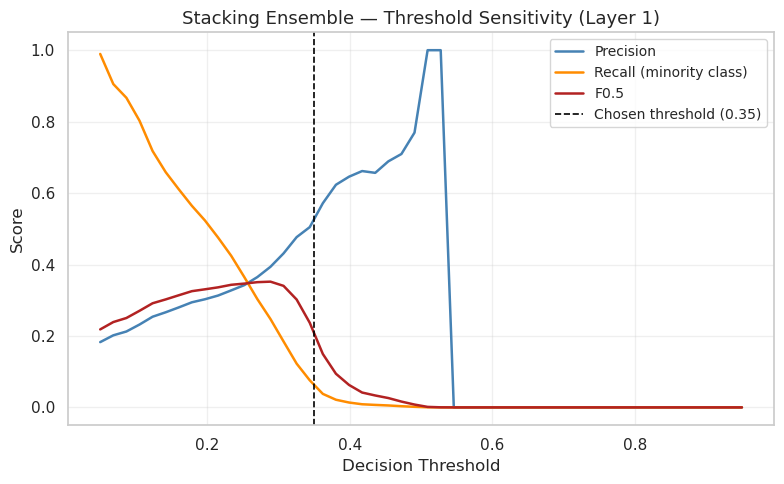

In [15]:
import numpy as np

# Sample down for speed — 20% is plenty
pdf = (stack_preds_l1
       .select("is_late", "probability")
       .sample(fraction=0.2, seed=42)
       .toPandas())

scores  = pdf["probability"].apply(lambda x: float(x[1])).values
labels  = pdf["is_late"].astype(int).values

thresholds = np.linspace(0.05, 0.95, 50)
precisions, recalls, f05s = [], [], []

for t in thresholds:
    preds = (scores >= t).astype(int)
    tp = ((preds == 1) & (labels == 1)).sum()
    fp = ((preds == 1) & (labels == 0)).sum()
    fn = ((preds == 0) & (labels == 1)).sum()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    beta = 0.5
    f05  = (1 + beta**2) * prec * rec / (beta**2 * prec + rec) if (prec + rec) > 0 else 0.0
    
    precisions.append(prec)
    recalls.append(rec)
    f05s.append(f05)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions, color="steelblue",  linewidth=1.8, label="Precision")
ax.plot(thresholds, recalls,    color="darkorange",  linewidth=1.8, label="Recall (minority class)")
ax.plot(thresholds, f05s,       color="firebrick",   linewidth=1.8, label="F0.5")
ax.axvline(x=0.35, color="black", linestyle="--", linewidth=1.2, label="Chosen threshold (0.35)")

ax.set_xlabel("Decision Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Stacking Ensemble — Threshold Sensitivity (Layer 1)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("stacking_threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

26/05/04 08:58:01 WARN DAGScheduler: Broadcasting large task binary with size 1173.9 KiB
26/05/04 08:58:01 WARN DAGScheduler: Broadcasting large task binary with size 1180.5 KiB
26/05/04 08:58:02 WARN DAGScheduler: Broadcasting large task binary with size 1167.6 KiB
26/05/04 08:58:02 WARN DAGScheduler: Broadcasting large task binary with size 1176.9 KiB
26/05/04 08:58:02 WARN DAGScheduler: Broadcasting large task binary with size 1186.3 KiB


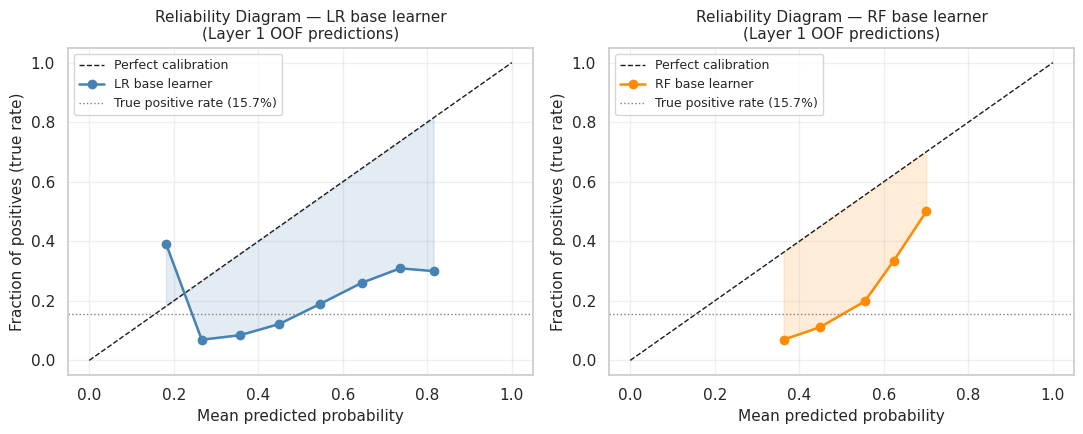

In [14]:
# meta_train_l1 has columns: row_id, is_late, lr_prob, rf_prob
cal_pdf = meta_train_l1.sample(fraction=0.1, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
n_bins = 10

for ax, prob_col, label, color in [
    (axes[0], "lr_prob", "LR base learner",  "steelblue"),
    (axes[1], "rf_prob", "RF base learner",  "darkorange"),
]:
    probs  = cal_pdf[prob_col].values
    labels = cal_pdf["is_late"].astype(int).values
    
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_means_pred, bin_means_true = [], []
    
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() > 0:
            bin_means_pred.append(probs[mask].mean())
            bin_means_true.append(labels[mask].mean())
    
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.plot(bin_means_pred, bin_means_true, "o-", color=color,
            linewidth=1.8, markersize=6, label=label)
    ax.fill_between(bin_means_pred, bin_means_pred, bin_means_true,
                    alpha=0.15, color=color)
    
    # Shade the underconfident region
    ax.axhline(y=0.157, color="grey", linestyle=":", linewidth=1,
               label="True positive rate (15.7%)")
    
    ax.set_xlabel("Mean predicted probability", fontsize=11)
    ax.set_ylabel("Fraction of positives (true rate)", fontsize=11)
    ax.set_title(f"Reliability Diagram — {label}\n(Layer 1 OOF predictions)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("calibration_reliability_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Layer 2 stack

In [16]:
print("="*60)
print("LAYER 2 STACK: LR + RF")
print("="*60)

t0 = time.time()

meta_train_l2 = build_oof_meta_features(
    df_train_id=train_l2_id,
    label_col="delay_severity",
    base_model_factory=get_base_models_l2,
    n_folds=5
)

meta_test_l2, fitted_l2 = build_test_meta_features(
    train_full_id=train_l2_id,
    test_id=test_l2_id,
    label_col="delay_severity",
    base_model_factory=get_base_models_l2
)

# Get raw meta-model
stack_model_l2, stack_preds_l2, res_l2 = fit_stack(
    meta_train=meta_train_l2,
    meta_test=meta_test_l2,
    label_col="delay_severity",
    model_name="Stacking Layer 2"
)

res_l2["train_time"] = time.time() - t0

LAYER 2 STACK: LR + RF
Fold 1/5


26/05/04 09:02:42 WARN CacheManager: Asked to cache already cached data.
26/05/04 09:02:53 WARN DAGScheduler: Broadcasting large task binary with size 1054.5 KiB
26/05/04 09:02:55 WARN DAGScheduler: Broadcasting large task binary with size 1509.1 KiB
26/05/04 09:02:56 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


Fold 2/5


26/05/04 09:03:08 WARN DAGScheduler: Broadcasting large task binary with size 1069.6 KiB
26/05/04 09:03:10 WARN DAGScheduler: Broadcasting large task binary with size 1522.0 KiB
26/05/04 09:03:12 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


Fold 3/5


...

26/05/04 09:03:56 WARN DAGScheduler: Broadcasting large task binary with size 1050.0 KiB
26/05/04 09:03:57 WARN DAGScheduler: Broadcasting large task binary with size 1493.2 KiB
26/05/04 09:03:59 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB


Training full lr model...
Training full rf model...


26/05/04 09:04:13 WARN DAGScheduler: Broadcasting large task binary with size 1041.1 KiB
26/05/04 09:04:15 WARN DAGScheduler: Broadcasting large task binary with size 1497.4 KiB
26/05/04 09:04:17 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/04 09:04:20 WARN DAGScheduler: Broadcasting large task binary with size 1150.6 KiB
26/05/04 09:04:20 WARN DAGScheduler: Broadcasting large task binary with size 1150.4 KiB
26/05/04 09:04:20 WARN DAGScheduler: Broadcasting large task binary with size 1154.2 KiB
26/05/04 09:04:20 WARN DAGScheduler: Broadcasting large task binary with size 1149.6 KiB
26/05/04 09:04:20 WARN DAGScheduler: Broadcasting large task binary with size 1130.2 KiB
26/05/04 09:04:21 WARN DAGScheduler: Broadcasting large task binary with size 1149.6 KiB
26/05/04 09:04:21 WARN DAGScheduler: Broadcasting large task binary with size 1130.2 KiB
26/05/04 09:04:21 WARN DAGScheduler: Broadcasting large task binary with size 1154.2 KiB
26/05/04 09:04:21 WARN D


 Stacking Layer 2
 Accuracy: 0.5929
 Weighted Precision: 0.5931
 Weighted Recall: 0.5929
 F0.5 Score: 0.5931
 AUC-ROC: 0.6237


26/05/04 09:04:54 WARN DAGScheduler: Broadcasting large task binary with size 1161.5 KiB


## 13. Results table

In [17]:
results = [res_l1, res_l2]
results_df = pd.DataFrame(results)

results_df[["accuracy", "precision", "recall", "f05", "auc"]] = results_df[["accuracy", "precision", "recall", "f05", "auc"]].round(4)
results_df["train_time"] = results_df["train_time"].round(1).astype(str) + "s"

print("="*45)
print("RESULTS SUMMARY")
print("="*45)
print(results_df.to_string(index=False))

results_df.to_csv("results_stacking.csv", index=False)
print("Saved to results_stacking.csv")

RESULTS SUMMARY
           model  accuracy  precision  recall    f05    auc train_time
Stacking Layer 1    0.8208     0.7720  0.8208 0.7813 0.6797     634.9s
Stacking Layer 2    0.5929     0.5931  0.5929 0.5931 0.6237     131.2s
Saved to results_stacking.csv


## 14. Comparison chart

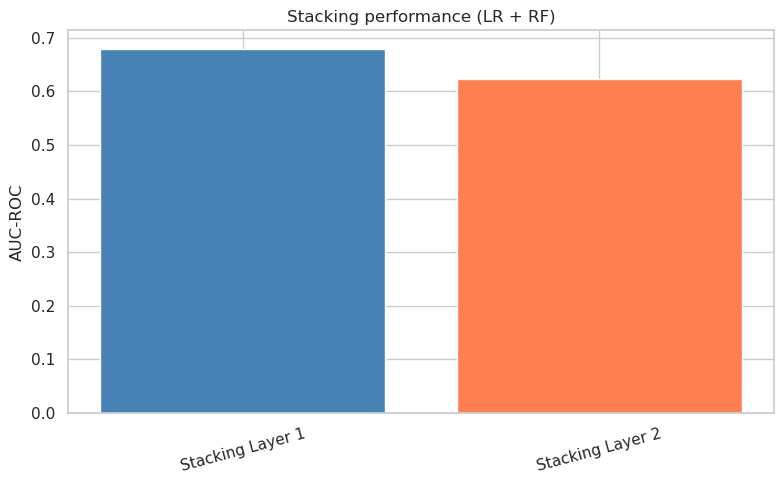

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["model"], results_df["auc"], color=["steelblue", "coral"])
plt.ylabel("AUC-ROC")
plt.title("Stacking performance (LR + RF)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("stacking.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Confusion Matricies

In [19]:
print("="*45)
print("CONFUSION MATRICES")
print("="*45)

def print_confusion_matrix(preds, label_col, title):
    print(f"\n{title}")
    total = preds.count()
    cm = preds.groupBy(label_col, "prediction") \
               .count() \
               .orderBy(label_col, "prediction") \
               .toPandas()
    cm["pct"] = (100 * cm["count"] / total).round(2)
    print(cm.to_string(index=False))

    tn = cm[(cm[label_col]==0.0) & (cm["prediction"]==0.0)]["count"].values
    fp = cm[(cm[label_col]==0.0) & (cm["prediction"]==1.0)]["count"].values
    fn = cm[(cm[label_col]==1.0) & (cm["prediction"]==0.0)]["count"].values
    tp = cm[(cm[label_col]==1.0) & (cm["prediction"]==1.0)]["count"].values

    tn = tn[0] if len(tn) > 0 else 0
    fp = fp[0] if len(fp) > 0 else 0
    fn = fn[0] if len(fn) > 0 else 0
    tp = tp[0] if len(tp) > 0 else 0

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0

    print(f"  TP: {tp:,}  TN: {tn:,}  FP: {fp:,}  FN: {fn:,}")
    print(f"  Precision: {precision:.4f}  Recall: {recall:.4f}  FPR: {fpr:.4f}")


print_confusion_matrix(stack_preds_l1,   "is_late",        "Layer 1 Stacking")
print_confusion_matrix(stack_preds_l2, "delay_severity",        "Layer 2 Stacking")

CONFUSION MATRICES

Layer 1 Stacking


26/05/04 09:04:55 WARN DAGScheduler: Broadcasting large task binary with size 1165.7 KiB
26/05/04 09:04:58 WARN DAGScheduler: Broadcasting large task binary with size 1219.6 KiB
26/05/04 09:04:58 WARN DAGScheduler: Broadcasting large task binary with size 1212.5 KiB
26/05/04 09:04:58 WARN DAGScheduler: Broadcasting large task binary with size 1212.8 KiB
26/05/04 09:04:59 WARN DAGScheduler: Broadcasting large task binary with size 1211.2 KiB


 is_late  prediction  count   pct
       0         0.0 563566 80.98
       0         1.0   7031  1.01
       1         0.0 117675 16.91
       1         1.0   7634  1.10
  TP: 7,634  TN: 563,566  FP: 7,031  FN: 117,675
  Precision: 0.5206  Recall: 0.0609  FPR: 0.0123

Layer 2 Stacking


26/05/04 09:04:59 WARN DAGScheduler: Broadcasting large task binary with size 1107.9 KiB
26/05/04 09:04:59 WARN DAGScheduler: Broadcasting large task binary with size 1161.6 KiB
26/05/04 09:05:00 WARN DAGScheduler: Broadcasting large task binary with size 1154.5 KiB
26/05/04 09:05:00 WARN DAGScheduler: Broadcasting large task binary with size 1154.8 KiB


 delay_severity  prediction  count   pct
              0         0.0  43744 34.91
              0         1.0  20822 16.62
              1         0.0  30191 24.09
              1         1.0  30552 24.38
  TP: 30,552  TN: 43,744  FP: 20,822  FN: 30,191
  Precision: 0.5947  Recall: 0.5030  FPR: 0.3225


26/05/04 09:05:00 WARN DAGScheduler: Broadcasting large task binary with size 1153.3 KiB


In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score

#  Sample both layers
pdf_l1 = (stack_preds_l1
          .select("is_late", "probability")
          .sample(fraction=0.2, seed=42)
          .toPandas())

pdf_l2 = (stack_preds_l2
          .select("delay_severity", "probability")
          .sample(fraction=0.2, seed=42)
          .toPandas())

# Layer 1
scores_l1 = pdf_l1["probability"].apply(lambda x: float(x[1])).values
labels_l1 = pdf_l1["is_late"].astype(int).values
prec_l1, rec_l1, _ = precision_recall_curve(labels_l1, scores_l1)
ap_l1 = average_precision_score(labels_l1, scores_l1)

# Layer 2
scores_l2 = pdf_l2["probability"].apply(lambda x: float(x[1])).values
labels_l2 = pdf_l2["delay_severity"].astype(int).values
prec_l2, rec_l2, _ = precision_recall_curve(labels_l2, scores_l2)
ap_l2 = average_precision_score(labels_l2, scores_l2)

26/05/04 09:24:55 WARN DAGScheduler: Broadcasting large task binary with size 1165.7 KiB
26/05/04 09:25:00 WARN DAGScheduler: Broadcasting large task binary with size 1107.9 KiB


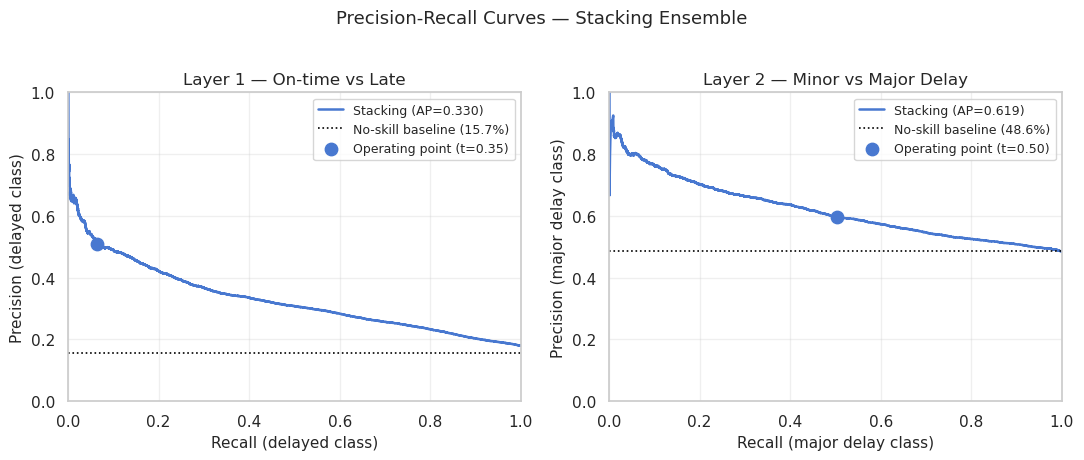

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

#  Layer 1 
ax = axes[0]
ax.plot(rec_l1, prec_l1, linewidth=1.8,
        label=f"Stacking (AP={ap_l1:.3f})")
ax.axhline(y=0.157, color="black", linestyle=":", linewidth=1.2,
           label="No-skill baseline (15.7%)")
ax.scatter(0.064, 0.508, s=80, zorder=5,
           label="Operating point (t=0.35)")
ax.set_xlabel("Recall (delayed class)", fontsize=11)
ax.set_ylabel("Precision (delayed class)", fontsize=11)
ax.set_title("Layer 1 — On-time vs Late", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

#  Layer 2 
ax = axes[1]
ax.plot(rec_l2, prec_l2, linewidth=1.8,
        label=f"Stacking (AP={ap_l2:.3f})")
ax.axhline(y=0.486, color="black", linestyle=":", linewidth=1.2,
           label="No-skill baseline (48.6%)")
# minority-class precision/recall from your Layer 2 CM
op_prec_l2 = 0.595   # TP/(TP+FP) = 30552/(30552+20822)
op_rec_l2  = 0.503   # TP/(TP+FN) = 30552/(30552+30191)
ax.scatter(op_rec_l2, op_prec_l2, s=80, zorder=5,
           label="Operating point (t=0.50)")
ax.set_xlabel("Recall (major delay class)", fontsize=11)
ax.set_ylabel("Precision (major delay class)", fontsize=11)
ax.set_title("Layer 2 — Minor vs Major Delay", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle("Precision-Recall Curves — Stacking Ensemble", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("stacking_pr_curves_l1_l2.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
from sklearn.metrics import roc_curve, auc

# Layer 1
fpr_l1, tpr_l1, _ = roc_curve(labels_l1, scores_l1)
auc_l1 = auc(fpr_l1, tpr_l1)

# Layer 2
fpr_l2, tpr_l2, _ = roc_curve(labels_l2, scores_l2)
auc_l2 = auc(fpr_l2, tpr_l2)

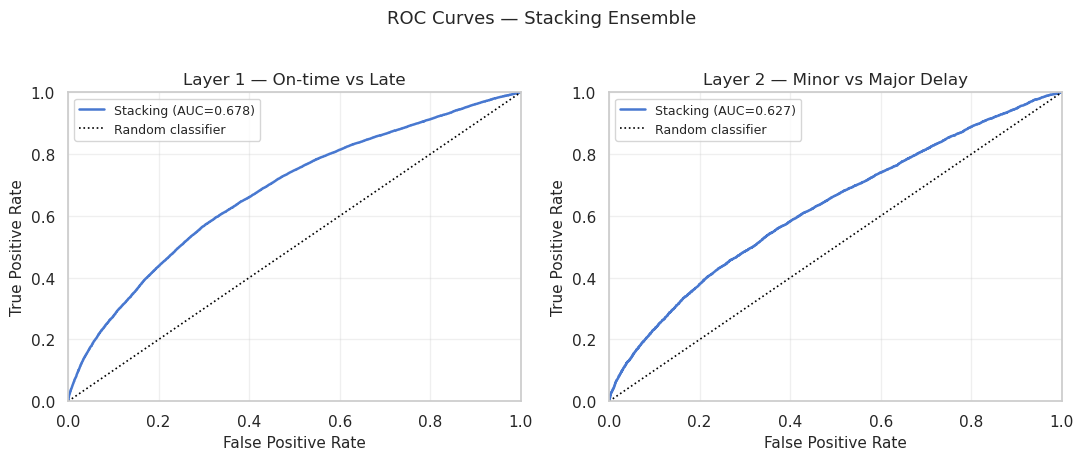

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Layer 1 
ax = axes[0]
ax.plot(fpr_l1, tpr_l1, linewidth=1.8,
        label=f"Stacking (AUC={auc_l1:.3f})")
ax.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1.2,
        label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("Layer 1 — On-time vs Late", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Layer 2 
ax = axes[1]
ax.plot(fpr_l2, tpr_l2, linewidth=1.8,
        label=f"Stacking (AUC={auc_l2:.3f})")
ax.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1.2,
        label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("Layer 2 — Minor vs Major Delay", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle("ROC Curves — Stacking Ensemble", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("stacking_roc_curves_l1_l2.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
spark.stop()